Predecir niveles de ruido cerca de aeropuerto.
Evaluar impacto acústico en zonas cercanas.
Datos de Dirección General de Aeronáutica Civil (DGAC)

Preguntas clave:
- ¿Qué factores influyen más en el ruido?
- ¿Hay diferencias según la aerolínea, hora o tipo de avión?
- ¿Por qué los sensores registran más ruido en las noches?


Diccionario de Variables
- NMT : Noise Monitoring Terminal: código del punto o estación de monitoreo de ruido.
- TLASmax : Timestamp de LASmax: fecha y hora de medición del nivel máximo de ruido.
- LASmax : Nivel máximo instantáneo de presión sonora ponderado A (dBA). Representa el mayor pico de ruido registrado durante el paso de una aeronave.
- SEL : Sound Exposure Level (dBA): Nivel de exposición sonora total de un evento de ruido, considerando duración y energía.
- Leq : Nivel equivalente (dBA): nivel continuo de presión sonora con la misma energía que el ruido fluctuante durante un período.
- LAZ : Nivel de ruido ponderado A con corrección de altitud o distancia (dBA). Es menos común, pero puede ser una medida ajustada.
- EPNL : Effective Perceived Noise Level (dB EPNL): Nivel de ruido percibido ajustado por la duración y características de la aeronave, usado en certificación aeronáutica.
- Temperature [°C] : Temperatura ambiental en grados Celsius. Puede influir en la propagación del sonido.
- A/D : Arrival / Departure: indica si el vuelo está aterrizando o despegando.
- Runway : Pista utilizada por la aeronave.
- Flight : Número de vuelo de la aeronave.
- Airline : Código IATA o ICAO de la aerolínea (ej: LAN, SKY).
- Airline (Name) : Nombre completo de la aerolínea.
- From/To : Ciudad o aeropuerto de origen o destino. Depende si es llegada o salida.
- Callsign : Identificador de radio usado por la aeronave.
- Aircraft Type : Tipo de aeronave.



EDA

In [ ]:
#descargar datos
import pandas as pd
df1 = pd.read_excel('../data/raw/NOISE TMR1.xlsx', skiprows=3)
df2 = pd.read_excel('../data/raw/NOISE TMR2.xlsx', skiprows=3)
df3 = pd.read_excel('../data/raw/NOISE TMR3.xlsx', skiprows=3)

#unir los tres dataframes
df = pd.concat([df1, df2, df3], ignore_index=True)
df

#Cambiar medicion a traves de funcion
#DGAC // aeropuertos << ruido amb << informe anual 2024

,NMT,TLASmax,LASmax,SEL,Leq,LAZ,EPNL,Temperature [°C],A/D,Runway,Flight,Airline,Airline (Name),From/To,Callsign,Aircraft Type
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MP01,01/01/2024 0:00:34,90.9,98.7,85.0,90.5,99.6,16.3,Arrival,17L,SKU172,SKU,Sky Airline,SCIE,SKU172,A20N
2,MP01,01/01/2024 0:02:56,91.3,99.1,82.2,89.6,100.4,16.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MP01,01/01/2024 0:03:57,95.3,102.2,88.4,90.5,104.7,16.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MP01,01/01/2024 0:04:12,96.0,99.9,90.4,87.9,101.8,16.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284307,MP03,30/12/2024 23:43:56,67.6,77.4,62.1,69.0,78.1,19.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284308,MP03,30/12/2024 23:44:11,69.6,76.3,64.0,67.2,77.3,19.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284309,MP03,30/12/2024 23:44:28,66.1,72.0,64.6,60.2,73.0,19.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284310,MP03,30/12/2024 23:44:50,67.2,79.6,63.9,70.8,80.8,19.3,Departure,17R,AMX011,AMX,Aeromexico,MMMX,AMX011,B789


In [4]:
#borrar primera fila
df = df.drop(index=0)

In [5]:
#tratar fecha
df['TLASmax'] = pd.to_datetime(df['TLASmax'], format='%d/%m/%Y %H:%M:%S')
df['Date'] = df['TLASmax'].dt.date
df['Hour'] = df['TLASmax'].dt.hour
df['DayOfWeek'] = df['TLASmax'].dt.day_name()

In [6]:
#Tratamiento de duplicados
sum_dupli = df.duplicated().sum()
print(f'Se encontraron {sum_dupli} filas duplicadas')

Se encontraron 1 filas duplicadas


In [7]:
df = df.drop_duplicates()

In [8]:
#porcentaje de nulos de las columnas
def porcentaje_nulos(df):
    return df.isnull().sum() * 100 / len(df)
porcentaje_nulos(df)

NMT                  0.000352
TLASmax              0.000352
LASmax               0.000352
SEL                  0.000352
Leq                  0.000352
LAZ                  0.000352
EPNL                 1.071366
Temperature [°C]     0.211389
A/D                 45.474306
Runway              45.756041
Flight              45.474306
Airline             45.474306
Airline (Name)      54.851043
From/To             45.474306
Callsign            45.474306
Aircraft Type       45.474306
Date                 0.000352
Hour                 0.000352
DayOfWeek            0.000352
dtype: float64

Alternativas a seguir:
- eliminar filas de columnas problematicas.
- Imputar EPNL basandonos en otras metricas (KNN imputer)
- Si quedan nulos en columnas no numéricas, se reemplaza con "Desconocido".

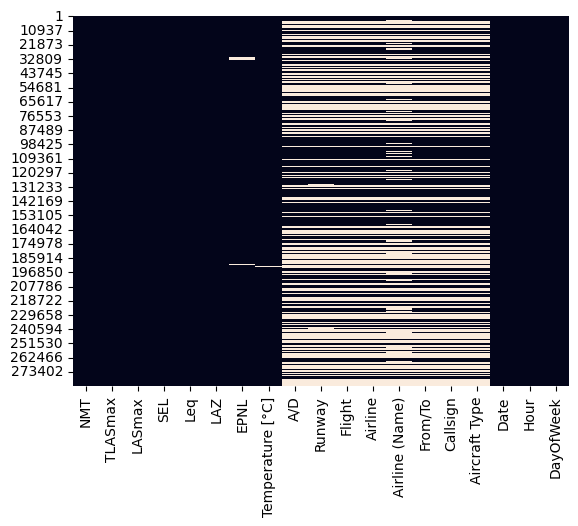

<Axes: >

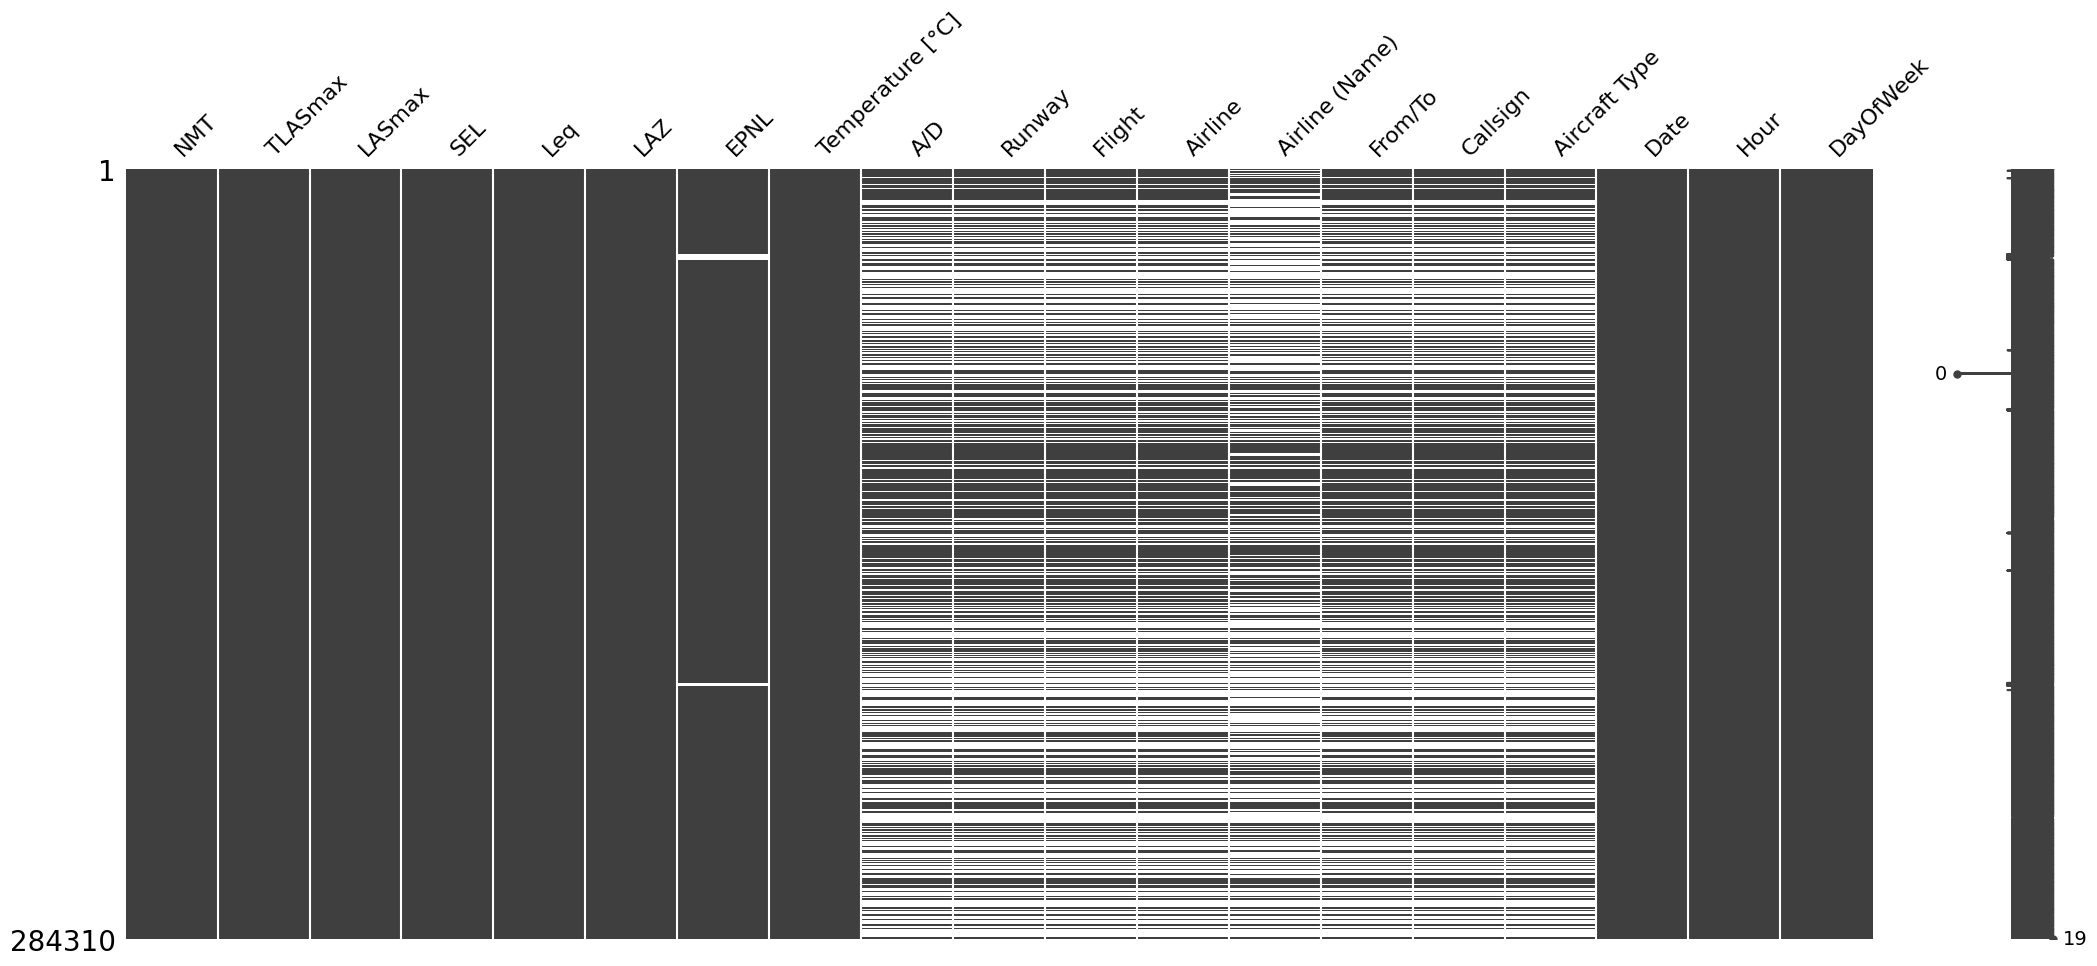

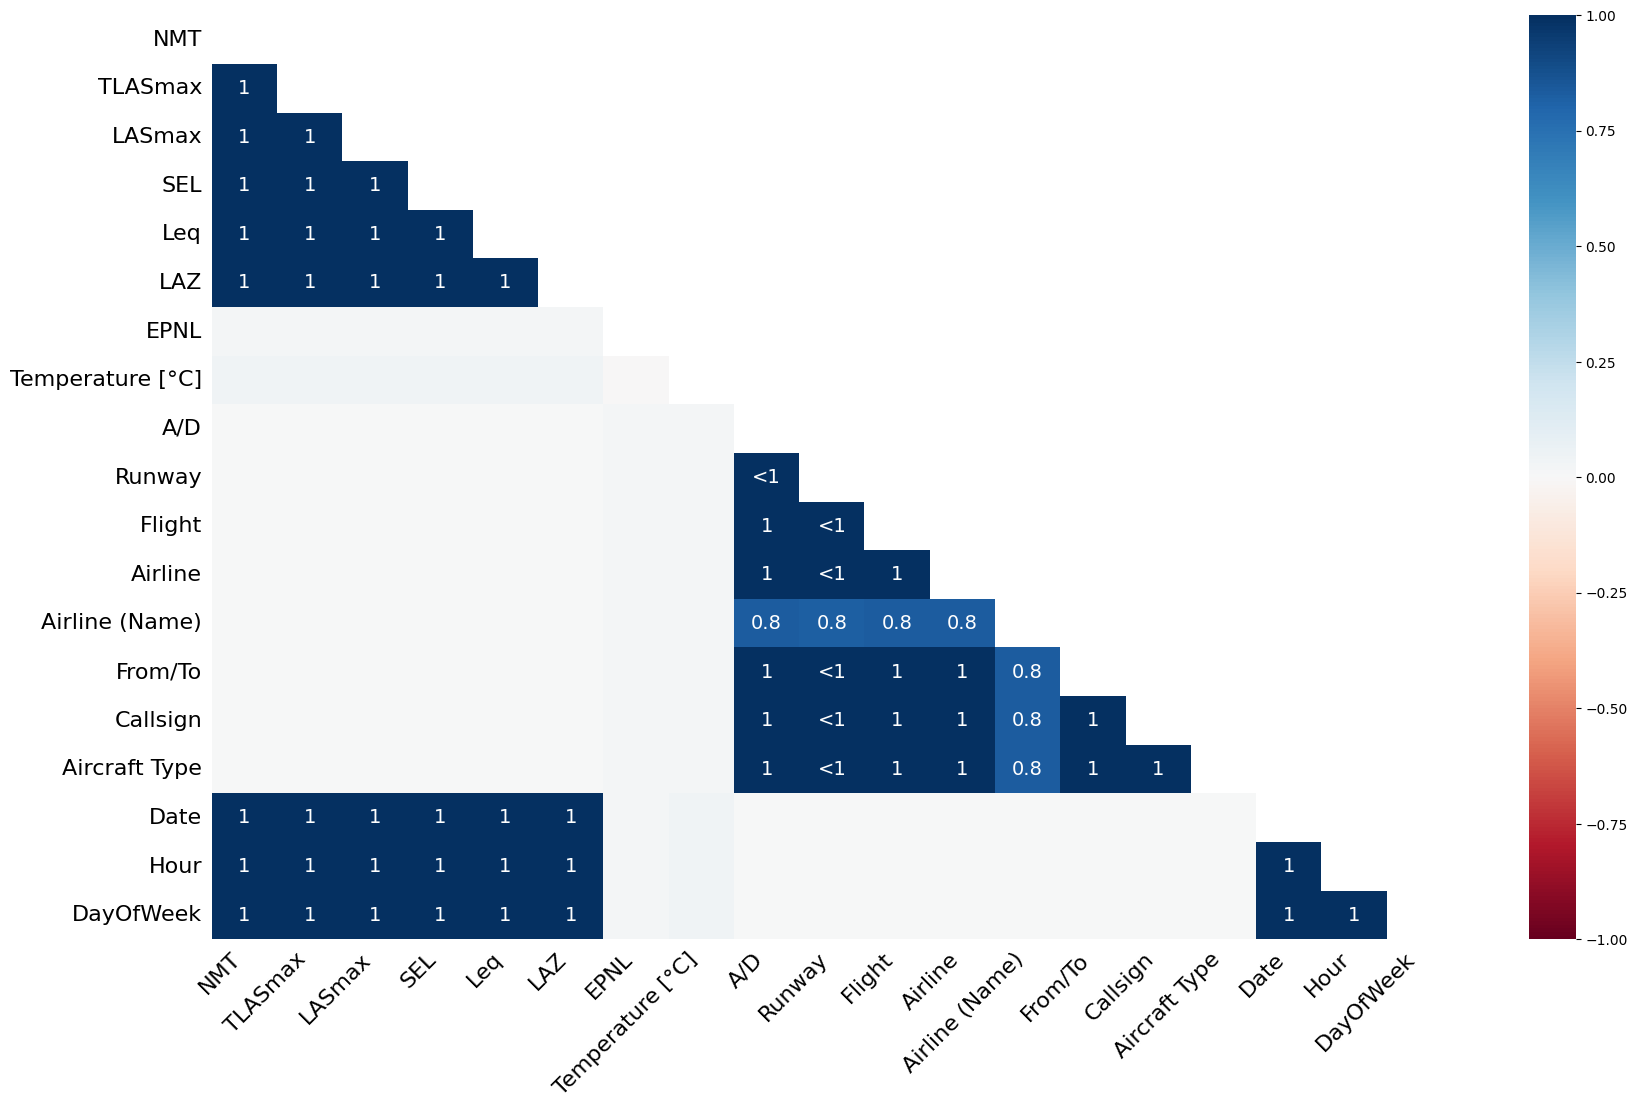

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Heatmap de nulos
sns.heatmap(df.isnull(), cbar=False)
plt.show()

# Visualización con missingno (mejor aún)
msno.matrix(df)
msno.heatmap(df)

Matriz de nulos por filas y columnas:
- Las primeras 6 columnas estan completas.
- EPNL tiene pocos nulos se puede imputar por la media o KNN imputer
- Las variables categoricas (descartando los sensores) presentan una significativa cantidad de nulos.

Correlación de nulos entre columnas:
- Los valores 1 indican que los nulos aparecen exactamente en los mismos registros.
- Las columnas A/D, Runway, Flight, Airline, From/To, Callsign, Aircraft Type y Airline (Name) están fuertemente correlacionadas en su patrón de nulos.
- Esto sugiere que cuando falta uno, generalmente faltan todos, probablemente porque esos registros no contienen información del vuelo.



In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 284310 entries, 1 to 284311
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   NMT               284309 non-null  object        
 1   TLASmax           284309 non-null  datetime64[ns]
 2   LASmax            284309 non-null  float64       
 3   SEL               284309 non-null  float64       
 4   Leq               284309 non-null  float64       
 5   LAZ               284309 non-null  float64       
 6   EPNL              281264 non-null  float64       
 7   Temperature [°C]  283709 non-null  float64       
 8   A/D               155022 non-null  object        
 9   Runway            154221 non-null  object        
 10  Flight            155022 non-null  object        
 11  Airline           155022 non-null  object        
 12  Airline (Name)    128363 non-null  object        
 13  From/To           155022 non-null  object        
 14  Callsign 

In [11]:
df1 = df.copy()
#Eliminar filas que no tienen ninguna variable de ruido
df1 = df1.dropna(subset=['SEL', 'Leq', 'LASmax', 'TLASmax', 'LAZ'])

#Eliminar columnas poco útiles con >50% nulos
df1 = df1.drop(columns=['Airline (Name)'])

#Imputar temperatura con mediana
df1['Temperature [°C]'] = df1['Temperature [°C]'].fillna(df1['Temperature [°C]'].median())

#Rellenar nulos categóricos con "Desconocido"
categ_cols = ['A/D', 'Runway', 'Flight', 'Airline', 'From/To', 'Callsign', 'Aircraft Type']
for col in categ_cols:
    df1[col] = df1[col].fillna('Desconocido')



In [12]:
#buscando otro tratamiento de nulos
df2 = df.copy()
#Eliminar todos los nulos
df2 = df2.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126490 entries, 1 to 284311
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   NMT               126490 non-null  object        
 1   TLASmax           126490 non-null  datetime64[ns]
 2   LASmax            126490 non-null  float64       
 3   SEL               126490 non-null  float64       
 4   Leq               126490 non-null  float64       
 5   LAZ               126490 non-null  float64       
 6   EPNL              126490 non-null  float64       
 7   Temperature [°C]  126490 non-null  float64       
 8   A/D               126490 non-null  object        
 9   Runway            126490 non-null  object        
 10  Flight            126490 non-null  object        
 11  Airline           126490 non-null  object        
 12  Airline (Name)    126490 non-null  object        
 13  From/To           126490 non-null  object        
 14  Callsign 

In [13]:
df3 = df.copy()
#Se deja tal cual para aplicar catboost
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 284310 entries, 1 to 284311
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   NMT               284309 non-null  object        
 1   TLASmax           284309 non-null  datetime64[ns]
 2   LASmax            284309 non-null  float64       
 3   SEL               284309 non-null  float64       
 4   Leq               284309 non-null  float64       
 5   LAZ               284309 non-null  float64       
 6   EPNL              281264 non-null  float64       
 7   Temperature [°C]  283709 non-null  float64       
 8   A/D               155022 non-null  object        
 9   Runway            154221 non-null  object        
 10  Flight            155022 non-null  object        
 11  Airline           155022 non-null  object        
 12  Airline (Name)    128363 non-null  object        
 13  From/To           155022 non-null  object        
 14  Callsign 

In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 284309 entries, 1 to 284311
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   NMT               284309 non-null  object        
 1   TLASmax           284309 non-null  datetime64[ns]
 2   LASmax            284309 non-null  float64       
 3   SEL               284309 non-null  float64       
 4   Leq               284309 non-null  float64       
 5   LAZ               284309 non-null  float64       
 6   EPNL              281264 non-null  float64       
 7   Temperature [°C]  284309 non-null  float64       
 8   A/D               284309 non-null  object        
 9   Runway            284309 non-null  object        
 10  Flight            284309 non-null  object        
 11  Airline           284309 non-null  object        
 12  From/To           284309 non-null  object        
 13  Callsign          284309 non-null  object        
 14  Aircraft 

In [15]:
#transformar TLASmax a datetime
df1['TLASmax'] = pd.to_datetime(df1['TLASmax'], format='dd/MM/yyyy HH:mm:ss', errors='coerce')
df1


,NMT,TLASmax,LASmax,SEL,Leq,LAZ,EPNL,Temperature [°C],A/D,Runway,Flight,Airline,From/To,Callsign,Aircraft Type,Date,Hour,DayOfWeek
1,MP01,2024-01-01 00:00:34,90.9,98.7,85.0,90.5,99.6,16.3,Arrival,17L,SKU172,SKU,SCIE,SKU172,A20N,2024-01-01,0.0,Monday
2,MP01,2024-01-01 00:02:56,91.3,99.1,82.2,89.6,100.4,16.2,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,2024-01-01,0.0,Monday
3,MP01,2024-01-01 00:03:57,95.3,102.2,88.4,90.5,104.7,16.3,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,2024-01-01,0.0,Monday
4,MP01,2024-01-01 00:04:12,96.0,99.9,90.4,87.9,101.8,16.3,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,2024-01-01,0.0,Monday
5,MP01,2024-01-01 00:04:29,92.8,102.0,87.9,93.6,103.1,16.3,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,2024-01-01,0.0,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284307,MP03,2024-12-30 23:43:56,67.6,77.4,62.1,69.0,78.1,19.3,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,2024-12-30,23.0,Monday
284308,MP03,2024-12-30 23:44:11,69.6,76.3,64.0,67.2,77.3,19.3,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,2024-12-30,23.0,Monday
284309,MP03,2024-12-30 23:44:28,66.1,72.0,64.6,60.2,73.0,19.3,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,2024-12-30,23.0,Monday
284310,MP03,2024-12-30 23:44:50,67.2,79.6,63.9,70.8,80.8,19.3,Departure,17R,AMX011,AMX,MMMX,AMX011,B789,2024-12-30,23.0,Monday


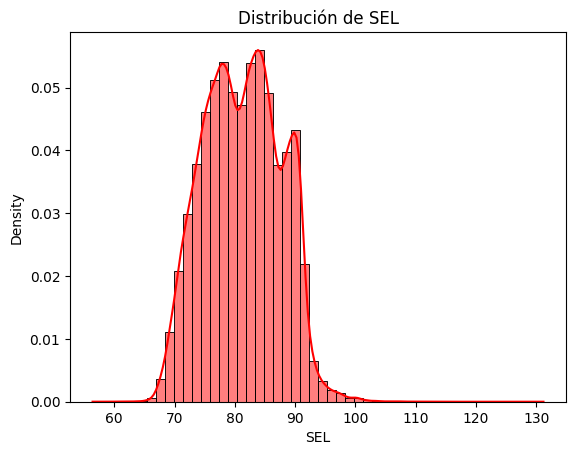

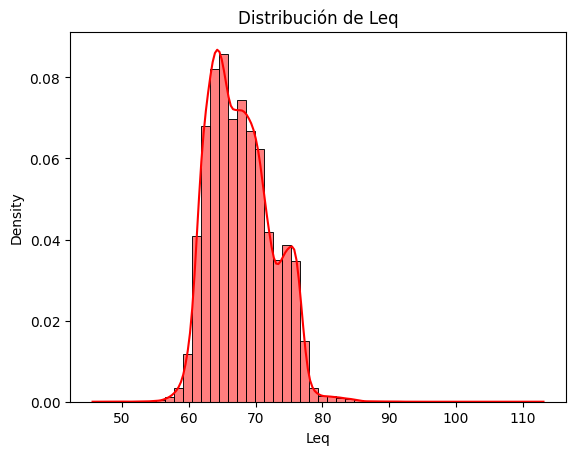

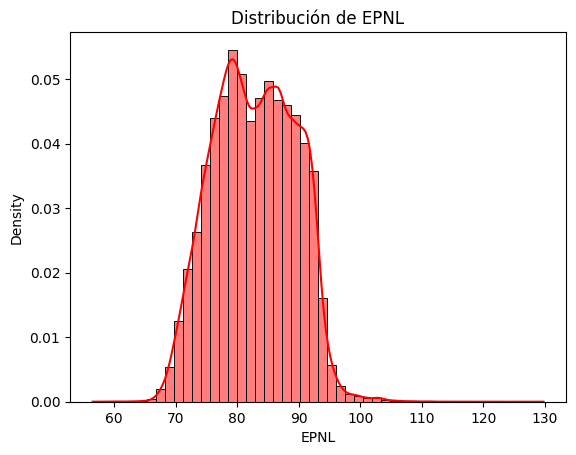

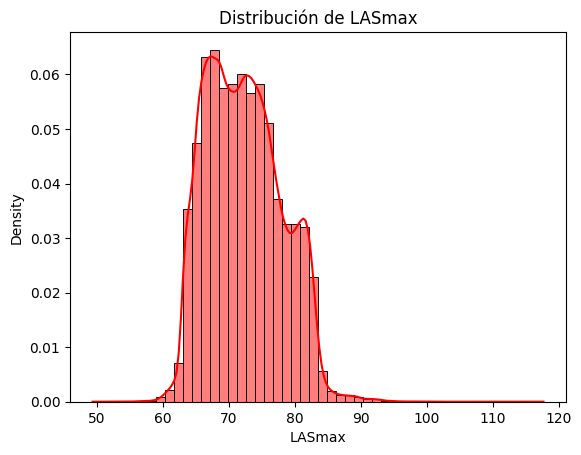

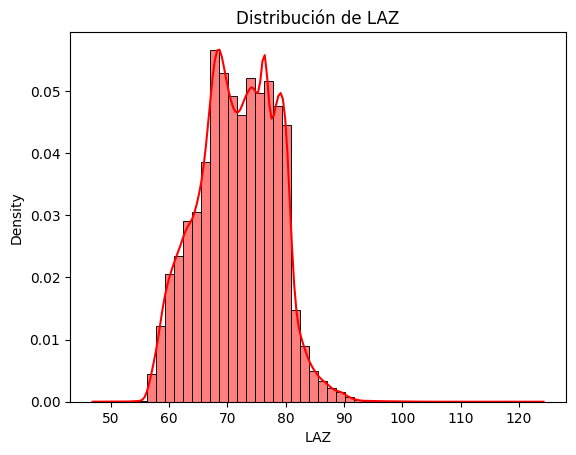

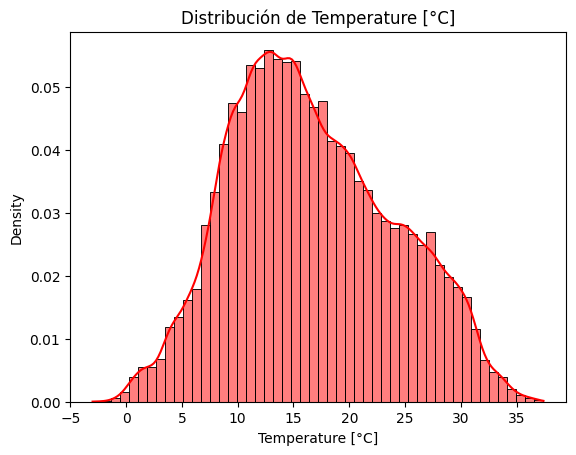

In [16]:

for col in ['SEL', 'Leq', 'EPNL', 'LASmax', 'LAZ', 'Temperature [°C]']:
    sns.histplot(df[col], kde=True, bins=50, color='red', stat='density')
    plt.title(f'Distribución de {col}')
    plt.show()

In [17]:
df1.corr(numeric_only=True)['SEL'].sort_values(ascending=False)

SEL                 1.000000
LAZ                 0.969478
EPNL                0.964666
LASmax              0.867447
Leq                 0.843432
Hour               -0.139108
Temperature [°C]   -0.199498
Name: SEL, dtype: float64

<Axes: >

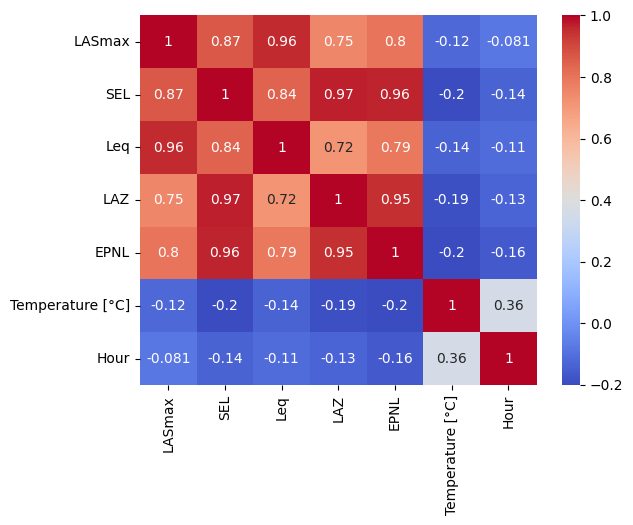

In [18]:
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')

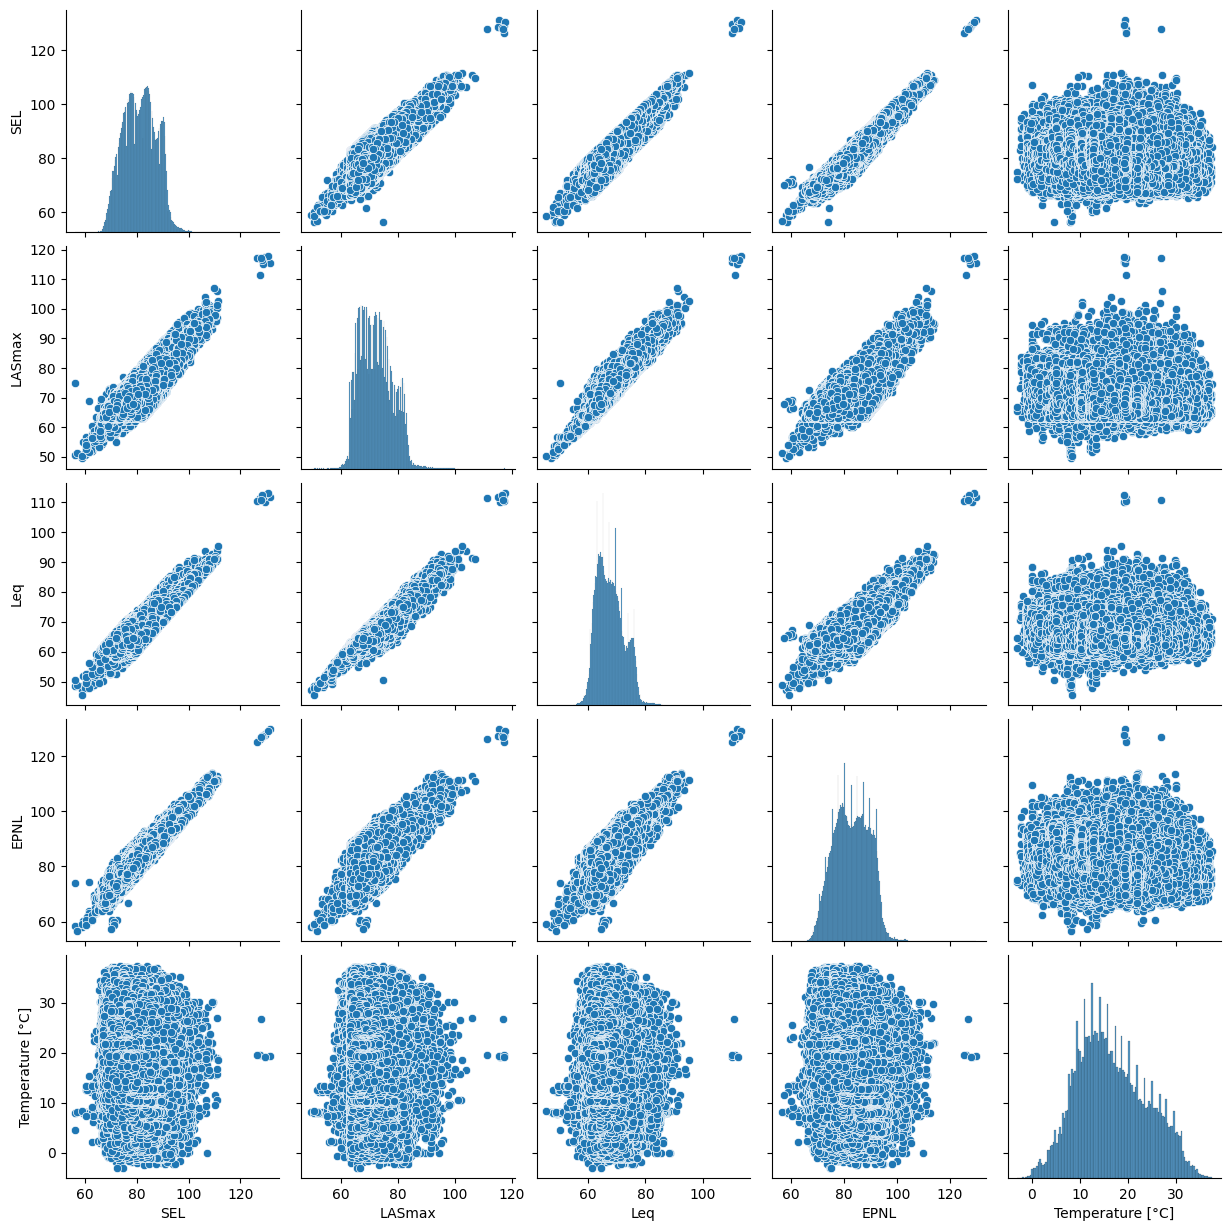

In [19]:
sns.pairplot(df[['SEL', 'LASmax', 'Leq', 'EPNL', 'Temperature [°C]']])
plt.show()

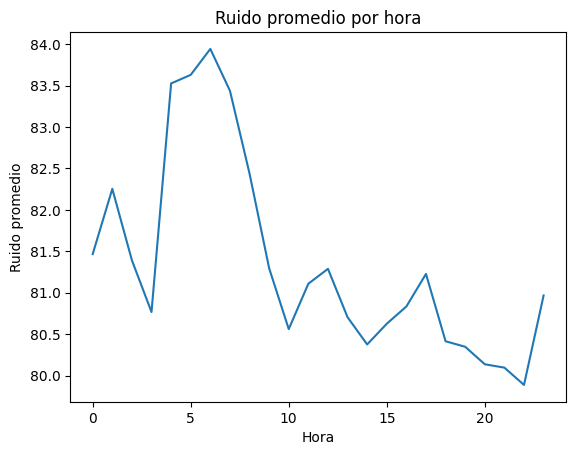

In [ ]:
#graficar ruido vs hora al dia
df.groupby("Hour")["SEL"].mean().plot()
plt.title("Ruido promedio por hora")
plt.xlabel("Hora")
plt.ylabel("Ruido promedio")
plt.show()
#por sensor..............................................

In [ ]:
#Comparar día vs noche
df1["is_night"] = df1["Hour"].apply(lambda x: x < 7 or x > 22) # ejemplo
df1.groupby("is_night")["SEL"].describe()


,count,mean,std,min,25%,50%,75%,max
is_night,,,,,,,,
False,211040.0,81.199590,6.27255,56.4,76.3,81.2,85.8,131.2
True,73269.0,81.458707,6.41792,56.8,76.4,81.7,86.5,107.3


In [22]:
#Analizar por sensor (NMT)
df1.groupby(["NMT", "is_night"])["SEL"].mean().unstack()

is_night,False,True
NMT,,
MP01,79.613780,79.064949
MP02,84.327467,85.604133
MP03,80.098318,79.671261


Observación:
- El sensor MP02 muestra un leve aumento de ruido en las noches.


<Axes: xlabel='Temperature [°C]', ylabel='SEL'>

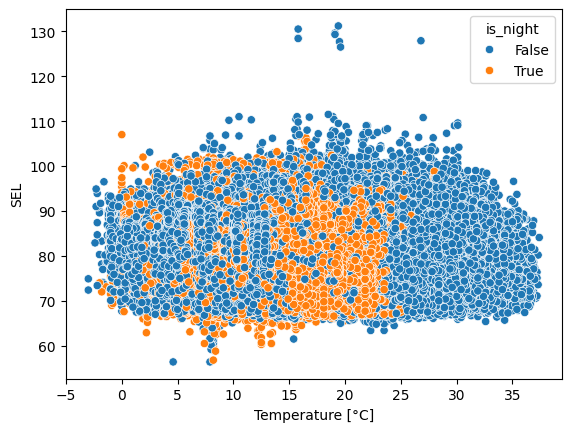

In [23]:
#Analizar influencia de temperatura
sns.scatterplot(data=df1, x="Temperature [°C]", y="SEL", hue="is_night")

Observación:
- Los niveles de SEL varían entre 60 dB y 130 dB, con concentraciones notables en el rango de 12 a 25 °C.
- En temperaturas extremas (>30 °C o <5 °C), el SEL no supera los 100 dB, pero esto podría deberse a menor actividad.

En general, no se aprecia una tendencia clara, quizas se deba a falta de variables como humedad y velocidad del viento.

In [24]:
#Un t-test entre SEL en día y noche para ver si la diferencia es estadísticamente significativa.
from scipy import stats
day_sel = df1[df1["is_night"] == False]["SEL"]
night_sel = df1[df1["is_night"] == True]["SEL"]
t_stat, p_value = stats.ttest_ind(day_sel, night_sel)
print(f"T-statistic: {t_stat}, P-value: {p_value}")
#Si el p-value es menor a 0.05, se rechaza la hipótesis nula de que no hay diferencia entre los dos grupos.

T-statistic: -9.576159323502175, P-value: 1.0148455606778733e-21


In [25]:
import numpy as np
pooled_std = np.sqrt(((len(day_sel)-1)*day_sel.std()**2 + (len(night_sel)-1)*night_sel.std()**2) / (len(day_sel) + len(night_sel) - 2))
cohens_d = (night_sel.mean() - day_sel.mean()) / pooled_std
print(f"Cohen's d: {cohens_d}")  
print(f"Media SEL día: {day_sel.mean():.2f}, noche: {night_sel.mean():.2f}")

Cohen's d: 0.04106238264912213
Media SEL día: 81.20, noche: 81.46


Observación: 
- Diferencia de medias (noche - día): 0.26 dB  
- Tamaño del efecto (Cohen's d): 0.041 (efecto mínimo)  
Interpretación: Aunque estadísticamente la diferencia es significativa, no tiene relevancia práctica.  

In [26]:
df1[df1["is_night"] == True]["Aircraft Type"].value_counts().head(10) 

Aircraft Type
Desconocido    32425
A321            8095
A320            7773
A20N            6013
A21N            3247
B789            2922
B788            2601
B738            2543
B763            1880
A359             930
Name: count, dtype: int64

In [27]:
df1[df1["is_night"] == True]["Airline"].value_counts().head(10)

Airline
Desconocido    32425
LAN            13719
SKU             4501
LXP             3983
JAT             3218
CMP             2719
TAM             1107
LPE              990
AAL              969
SKX              921
Name: count, dtype: int64

MODELO

In [28]:
features = [
    "Hour", "Temperature [°C]", "Aircraft Type",
    "NMT", "A/D", "Runway", "is_night"
]
target = "SEL"

df_model = df1[features + [target]].copy() 
# Convertir variables categóricas a dummies
df_model = pd.get_dummies(df_model, columns=["Aircraft Type", "NMT", "A/D", "Runway", "is_night"], drop_first=True)

In [29]:
from sklearn.model_selection import train_test_split

X = df_model.drop("SEL", axis=1)
y = df_model["SEL"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² score:", r2_score(y_test, y_pred))

MAE: 3.62885219279869
R² score: 0.3613433027164309


In [ ]:
#Agregar is_night a df2
df2["is_night"] = df2["Hour"].apply(lambda x: x < 7 or x > 22)  

In [32]:
df_model = df2[features + [target]].copy()  
df_model = pd.get_dummies(df_model, columns=["Aircraft Type", "NMT", "A/D", "Runway", "is_night"], drop_first=True)

X = df_model.drop("SEL", axis=1)
y = df_model["SEL"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² score:", r2_score(y_test, y_pred))

MAE: 2.382934362554998
R² score: 0.6195426155764865


In [33]:
df3 = df3.drop(columns=['TLASmax'])

In [34]:
df3.info()
# Convertir la columna Date a datetime
df3['Date'] = pd.to_datetime(df3['Date'], errors='coerce')

# Crear nuevas columnas a partir de la fecha
df3['year'] = df3['Date'].dt.year
df3['month'] = df3['Date'].dt.month
df3['day'] = df3['Date'].dt.day

# Eliminar la columna original de fecha
df3 = df3.drop(columns=['Date'])

<class 'pandas.core.frame.DataFrame'>
Index: 284310 entries, 1 to 284311
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   NMT               284309 non-null  object 
 1   LASmax            284309 non-null  float64
 2   SEL               284309 non-null  float64
 3   Leq               284309 non-null  float64
 4   LAZ               284309 non-null  float64
 5   EPNL              281264 non-null  float64
 6   Temperature [°C]  283709 non-null  float64
 7   A/D               155022 non-null  object 
 8   Runway            154221 non-null  object 
 9   Flight            155022 non-null  object 
 10  Airline           155022 non-null  object 
 11  Airline (Name)    128363 non-null  object 
 12  From/To           155022 non-null  object 
 13  Callsign          155022 non-null  object 
 14  Aircraft Type     155022 non-null  object 
 15  Date              284309 non-null  object 
 16  Hour              284309 

In [35]:
from catboost import CatBoostRegressor

#Metodo CatBoost
# Detectar columnas categóricas (tipo object o string)
cat_columns = df3.select_dtypes(include='object').columns.tolist() 
# Llenar los NaN en columnas categóricas con 'missing'
df3[cat_columns] = df3[cat_columns].fillna('missing') 

# Eliminar filas donde el target esté vacío (NaN)
df3 = df3[df3['SEL'].notna()] 
# Separar variables independientes (X) y target (y)
X = df3.drop(columns=['SEL'])
y = df3['SEL']
# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo con CatBoost
model = CatBoostRegressor(verbose=100)
model.fit(X_train, y_train, cat_features=cat_columns)

# Evaluar
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE con CatBoost: {mae:.4f}")

Learning rate set to 0.096509
0:	learn: 5.7490664	total: 306ms	remaining: 5m 5s
100:	learn: 0.5314702	total: 27.3s	remaining: 4m 2s
200:	learn: 0.4777660	total: 55s	remaining: 3m 38s
300:	learn: 0.4533420	total: 1m 22s	remaining: 3m 12s
400:	learn: 0.4394257	total: 1m 52s	remaining: 2m 47s
500:	learn: 0.4298142	total: 2m 19s	remaining: 2m 19s
600:	learn: 0.4224118	total: 2m 47s	remaining: 1m 51s
700:	learn: 0.4164369	total: 3m 15s	remaining: 1m 23s
800:	learn: 0.4114822	total: 3m 43s	remaining: 55.6s
900:	learn: 0.4072470	total: 4m 11s	remaining: 27.6s
999:	learn: 0.4041648	total: 4m 38s	remaining: 0us
MAE con CatBoost: 0.2988


In [36]:
r2 = r2_score(y_test, y_pred)
print(f"R² con CatBoost: {r2:.4f}")

R² con CatBoost: 0.9954


In [37]:
for col in df3.select_dtypes(include='object').columns:
    print(f"{col}: {df3[col].nunique()} valores únicos")

NMT: 3 valores únicos
A/D: 3 valores únicos
Runway: 5 valores únicos
Flight: 3140 valores únicos
Airline: 425 valores únicos
Airline (Name): 123 valores únicos
From/To: 255 valores únicos
Callsign: 3140 valores únicos
Aircraft Type: 189 valores únicos
DayOfWeek: 7 valores únicos


Muchos valores unicos, muy sobreajustado

In [38]:
df4 = df3.copy()

# Eliminar columnas altamente específicas que pueden causar overfitting
df4 = df4.drop(columns=['Flight', 'Callsign', 'Airline (Name)'])

# Agrupar From/To por país o usar solo el prefijo de 3 letras
df4['FromTo_prefix'] = df4['From/To'].str[:3]
df4 = df4.drop(columns=['From/To'])

cat_columns = df4.select_dtypes(include='object').columns.tolist()
df4[cat_columns] = df4[cat_columns].fillna('missing')

X = df4.drop(columns=['SEL'])
y = df4['SEL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(verbose=100)
model.fit(X_train, y_train, cat_features=cat_columns)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Learning rate set to 0.096509
0:	learn: 5.7507278	total: 189ms	remaining: 3m 8s
100:	learn: 0.5352427	total: 20.6s	remaining: 3m 3s
200:	learn: 0.4809290	total: 40.9s	remaining: 2m 42s
300:	learn: 0.4560945	total: 1m 1s	remaining: 2m 22s
400:	learn: 0.4416016	total: 1m 21s	remaining: 2m 1s
500:	learn: 0.4309250	total: 1m 41s	remaining: 1m 41s
600:	learn: 0.4229648	total: 2m 1s	remaining: 1m 20s
700:	learn: 0.4174329	total: 2m 21s	remaining: 1m
800:	learn: 0.4129025	total: 2m 42s	remaining: 40.3s
900:	learn: 0.4086110	total: 3m 2s	remaining: 20s
999:	learn: 0.4050683	total: 3m 22s	remaining: 0us
MAE: 0.299249431580497
R²: 0.9953719979556668


In [39]:
df6 = df3.copy()

# Eliminamos columnas acústicas (las que podrían contener fuga de información)
cols_to_drop = ['LASmax', 'Leq', 'LAZ', 'EPNL']
df6 = df6.drop(columns=cols_to_drop)

# eliminar 'Flight' y 'Callsign' por granularidad exagerada
df6 = df6.drop(columns=['Flight', 'Callsign'])

#por siacaso , pero por protocolo no se
df6 = df6[df6['SEL'].notna()]

# Llenar NaNs de categóricas con 'missing'
cat_cols = df6.select_dtypes(include='object').columns.tolist()
df6[cat_cols] = df6[cat_cols].fillna('missing')

# Entrenar modelo solo con esas columnas
X = df6.drop(columns=['SEL'])
y = df6['SEL']

from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(verbose=100)
model.fit(X_train, y_train, cat_features=cat_cols)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE con variables previas: {mae:.4f}")
print(f"R² con variables previas: {r2:.4f}")

Learning rate set to 0.096509
0:	learn: 6.1270738	total: 246ms	remaining: 4m 6s
100:	learn: 4.7945001	total: 19s	remaining: 2m 48s
200:	learn: 4.7180744	total: 39.4s	remaining: 2m 36s
300:	learn: 4.6808156	total: 59.5s	remaining: 2m 18s
400:	learn: 4.6480441	total: 1m 20s	remaining: 2m
500:	learn: 4.6261301	total: 1m 40s	remaining: 1m 40s
600:	learn: 4.6056151	total: 2m 1s	remaining: 1m 20s
700:	learn: 4.5876458	total: 2m 23s	remaining: 1m 1s
800:	learn: 4.5732458	total: 2m 44s	remaining: 40.9s
900:	learn: 4.5609352	total: 3m 5s	remaining: 20.4s
999:	learn: 4.5479061	total: 3m 27s	remaining: 0us
MAE con variables previas: 3.2322
R² con variables previas: 0.4710


In [40]:
from xgboost import XGBRegressor

X = df6.drop(columns=['SEL'])
y = df6['SEL']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo con XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"MAE con XGBoost: {mae_xgb:.4f}")
print(f"R² con XGBoost: {r2_xgb:.4f}")


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:NMT: object, A/D: object, Runway: object, Airline: object, Airline (Name): object, From/To: object, Aircraft Type: object, DayOfWeek: object